### Сбор полной выборки по инетерсующим кодам из UN Comtrade

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns

#### 1. Приведение к общему формату

In [37]:
comtrade = []

for year in range(2019, 2026):
    df = pd.read_csv(
        f'data/comtrade_{year}.csv',
        encoding="latin1", 
        sep=",",
        engine="python",      
        on_bad_lines="warn")
    comtrade.append(df)

comtrade = pd.concat(comtrade)
comtrade

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
C,M,20190101,2019,1,201901,31,AZE,Azerbaijan,X,Export,...,False,0.0,False,0.0,4.240,4.240,0,False,True,NaN
C,M,20190101,2019,1,201901,36,AUS,Australia,X,Export,...,True,30.0,False,NaN,12012.081,12012.081,6,False,True,NaN
C,M,20190101,2019,1,201901,51,ARM,Armenia,X,Export,...,False,0.0,False,0.0,64738.330,64738.330,0,False,True,NaN
C,M,20190101,2019,1,201901,56,BEL,Belgium,X,Export,...,False,0.0,False,0.0,7017737.278,7017737.278,2,False,True,NaN
C,M,20190101,2019,1,201901,76,BRA,Brazil,X,Export,...,False,0.0,False,NaN,3739.000,3739.000,0,False,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C,M,20251201,2025,12,202512,710,ZAF,South Africa,X,Export,...,True,0.0,False,NaN,251.570,251.570,4,False,True,NaN
C,M,20251201,2025,12,202512,826,GBR,United Kingdom,X,Export,...,False,0.0,False,NaN,5440.804,5440.804,0,False,True,NaN
C,M,20251201,2025,12,202512,826,GBR,United Kingdom,X,Export,...,False,0.0,False,NaN,1206729.294,1206729.294,0,False,True,NaN
C,M,20251201,2025,12,202512,826,GBR,United Kingdom,X,Export,...,False,0.0,False,NaN,5204517.236,5204517.236,0,False,True,NaN


In [38]:
comtrade = comtrade[[
    'freqCode', 'reporterISO', 'flowCode', 'isOriginalClassification',
    'fobvalue', 'qtyUnitCode', 'qtyUnitAbbr', 'altQtyUnitCode', 'altQtyUnitAbbr'
]]

comtrade = comtrade.rename(columns={
    'freqCode': 'Отчетный период', 'reporterISO': 'Страна-партнер',
    'flowCode': 'Направление', 'isOriginalClassification': 'Код товара (4 знака)',
    'fobvalue': 'Значение (стоимость)', 'qtyUnitAbbr': 'Значение (масса)',
    'qtyUnitCode': 'Единица объема', 'altQtyUnitAbbr': 'Дополнительная единица измерения (ДЭИ)',
    'altQtyUnitCode': 'ДЭИ, описание'
})

comtrade['Отчетный период'] = pd.to_datetime(comtrade['Отчетный период'], format='%Y%m%d')
comtrade['Код товара (4 знака)'] = comtrade['Код товара (4 знака)'].astype(str)
comtrade['Значение (стоимость)'] = comtrade['Значение (стоимость)'].astype(float)
comtrade['Значение (масса)'] = comtrade['Значение (масса)'].astype(float)
comtrade['Дополнительная единица измерения (ДЭИ)'] = comtrade['Дополнительная единица измерения (ДЭИ)'].astype(float)
comtrade

,Отчетный период,Страна-партнер,Направление,Код товара (4 знака),Значение (стоимость),Единица объема,Значение (масса),"ДЭИ, описание",Дополнительная единица измерения (ДЭИ)
C,2019-01-01,Azerbaijan,Export,9018,4.240,u,36.000,u,36.0
C,2019-01-01,Australia,Export,9018,12012.081,kg,28.633,NaN,0.0
C,2019-01-01,Armenia,Export,9018,64738.330,u,13836.000,u,13836.0
C,2019-01-01,Belgium,Export,9018,7017737.278,NaN,0.000,NaN,0.0
C,2019-01-01,Brazil,Export,9018,3739.000,u,28.000,u,28.0
...,...,...,...,...,...,...,...,...,...
C,2025-12-01,South Africa,Export,9031,251.570,u,2.000,u,2.0
C,2025-12-01,United Kingdom,Export,9018,5440.804,NaN,0.000,NaN,0.0
C,2025-12-01,United Kingdom,Export,9019,1206729.294,kg,2843.000,NaN,0.0
C,2025-12-01,United Kingdom,Export,9021,5204517.236,kg,3477.000,kg,3477.0


Оставим только те страны, которые мы не парсим или по которым есть проблемы. Только те страны, у которых есть недавние данные

In [20]:
new_countries = [
    'Azerbaijan', 'Australia', 'Armenia', 'Belarus',
    'Canada', 'Israel', 'Japan', 'Malaysia', 'Kazakhstan',
    'New Zealand', 'Pakistan', 'Philippines', 'Singapore', 'United Kingdom',
    'Viet Nam', 'South Africa', 'United Arab Emirates', 'Rep. of Moldova',
    'Egypt', 'Uruguay', 'Colombia', 'Kyrgyzstan', 'Andorra', 'Iceland',
    'Mongolia', 'Saudi Arabia', 'Morocco', 'Kenya', 'Trinidad and Tobago',
    'Indonesia', 'Chile', 'Uzbekistan', 'Mexico', 'Bolivia (Plurinational State of)',
    'Uganda', 'Namibia', 'United Rep. of Tanzania', 'Ecuador', 'Kuwait', 'Mozambique',
    'Qatar', 'Cambodia', 'Tunisia', 'Dominican Rep.', 'Angola', 'Oman', 'Bahrain', 'Mauritius'
]

comtrade = comtrade[comtrade['Страна-партнер'].isin(new_countries)]
max_date = comtrade.groupby('Страна-партнер', as_index=False)['Отчетный период'].max()
max_date = max_date.rename(columns={'Отчетный период': 'max_date'})
comtrade = comtrade.merge(max_date, on='Страна-партнер', how='left')
comtrade = comtrade[(comtrade['max_date'] >= '2025-06-01') | (comtrade['Страна-партнер'].isin(['Kazakhstan', 'United Kingdom', 'Australia']))]
comtrade

,Отчетный период,Страна-партнер,Направление,Код товара (4 знака),Значение (стоимость),Единица объема,Значение (масса),"ДЭИ, описание",Дополнительная единица измерения (ДЭИ),max_date
0,2019-01-01,Azerbaijan,Export,9018,4.240,u,36.000,u,36.000,2025-12-01
1,2019-01-01,Australia,Export,9018,12012.081,kg,28.633,NaN,0.000,2024-11-01
2,2019-01-01,Armenia,Export,9018,64738.330,u,13836.000,u,13836.000,2025-11-01
4,2019-01-01,Armenia,Export,9019,15350.530,kg,1625.270,kg,1625.270,2025-11-01
7,2019-01-01,Armenia,Export,9021,67851.380,kg,9137.164,kg,9137.164,2025-11-01
...,...,...,...,...,...,...,...,...,...,...
5845,2025-12-01,South Africa,Export,9031,251.570,u,2.000,u,2.000,2025-12-01
5846,2025-12-01,United Kingdom,Export,9018,5440.804,NaN,0.000,NaN,0.000,2025-12-01
5847,2025-12-01,United Kingdom,Export,9019,1206729.294,kg,2843.000,NaN,0.000,2025-12-01
5848,2025-12-01,United Kingdom,Export,9021,5204517.236,kg,3477.000,kg,3477.000,2025-12-01


In [21]:
series = comtrade.groupby(['Страна-партнер', 'Отчетный период'], as_index=False)['Значение (стоимость)'].sum()
series

,Страна-партнер,Отчетный период,Значение (стоимость)
0,Armenia,2019-01-01,234357.70
1,Armenia,2019-02-01,293996.91
2,Armenia,2019-03-01,433698.61
3,Armenia,2019-04-01,463833.57
4,Armenia,2019-05-01,750497.13
...,...,...,...
1277,Uzbekistan,2025-01-01,109019.00
1278,Uzbekistan,2025-02-01,314744.00
1279,Uzbekistan,2025-03-01,717943.00
1280,Uzbekistan,2025-04-01,333198.00


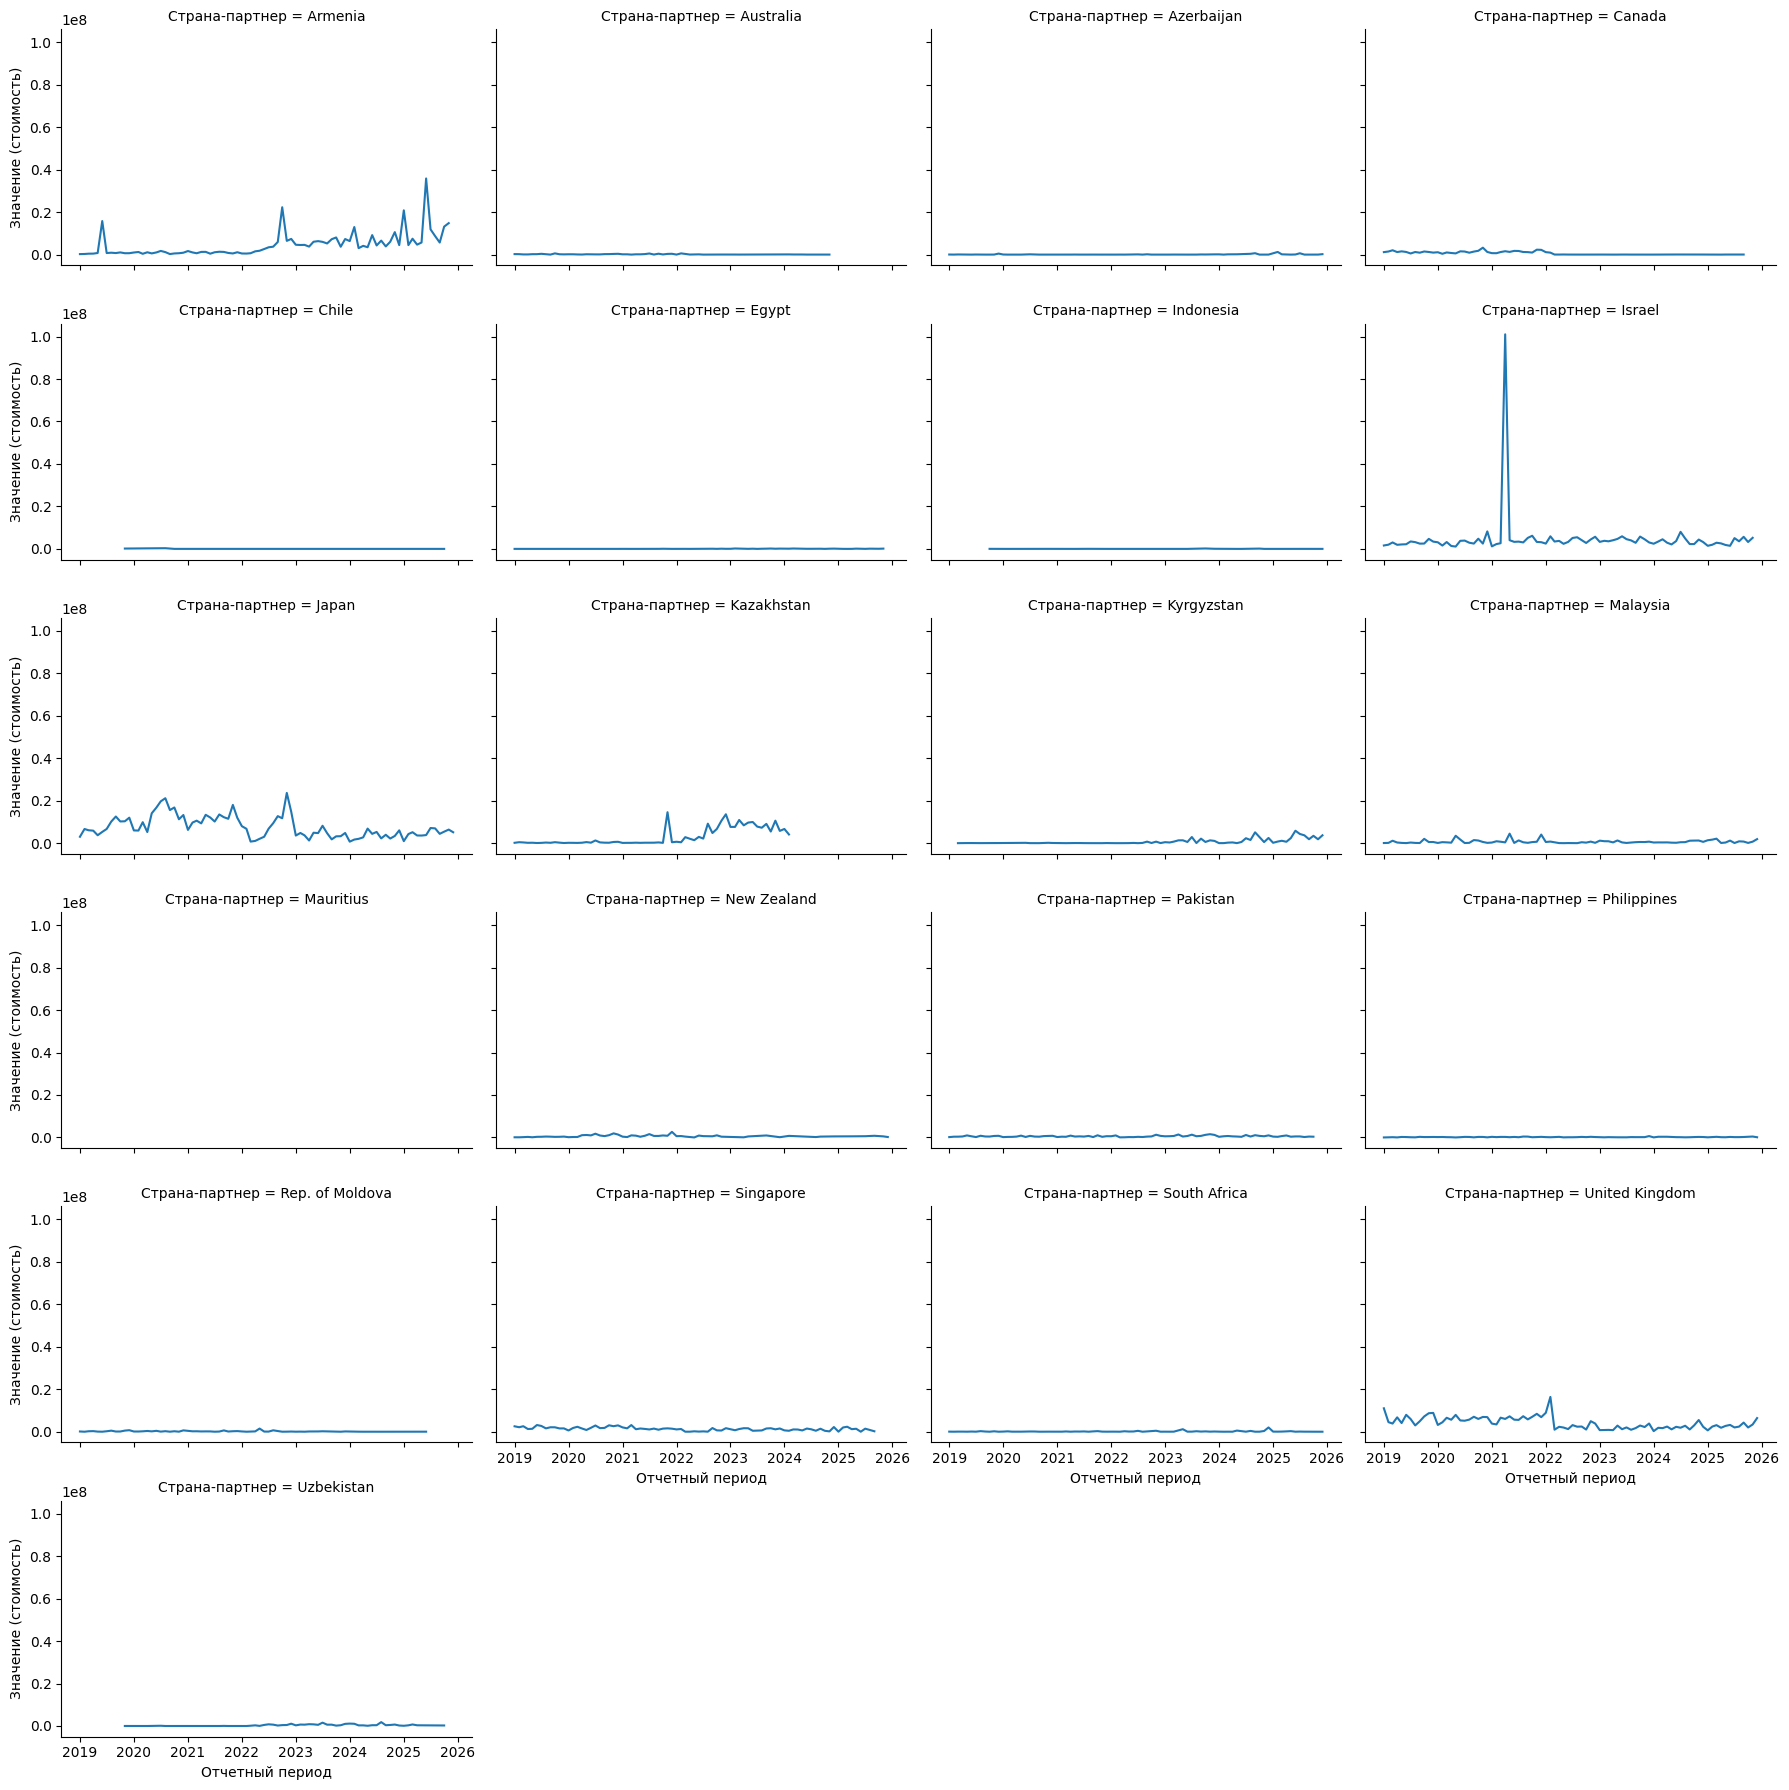

In [22]:
sns.relplot(
    data=series,
    x='Отчетный период',
    y='Значение (стоимость)',
    col='Страна-партнер',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

Исправим пик в Израиле

In [23]:
comtrade.loc[(comtrade['Страна-партнер'] == 'Israel') 
    & (comtrade['Значение (стоимость)'] > 1e+7), 'Значение (стоимость)'] = comtrade[(comtrade['Страна-партнер'] == 'Israel')]['Значение (стоимость)'].quantile(0.99)

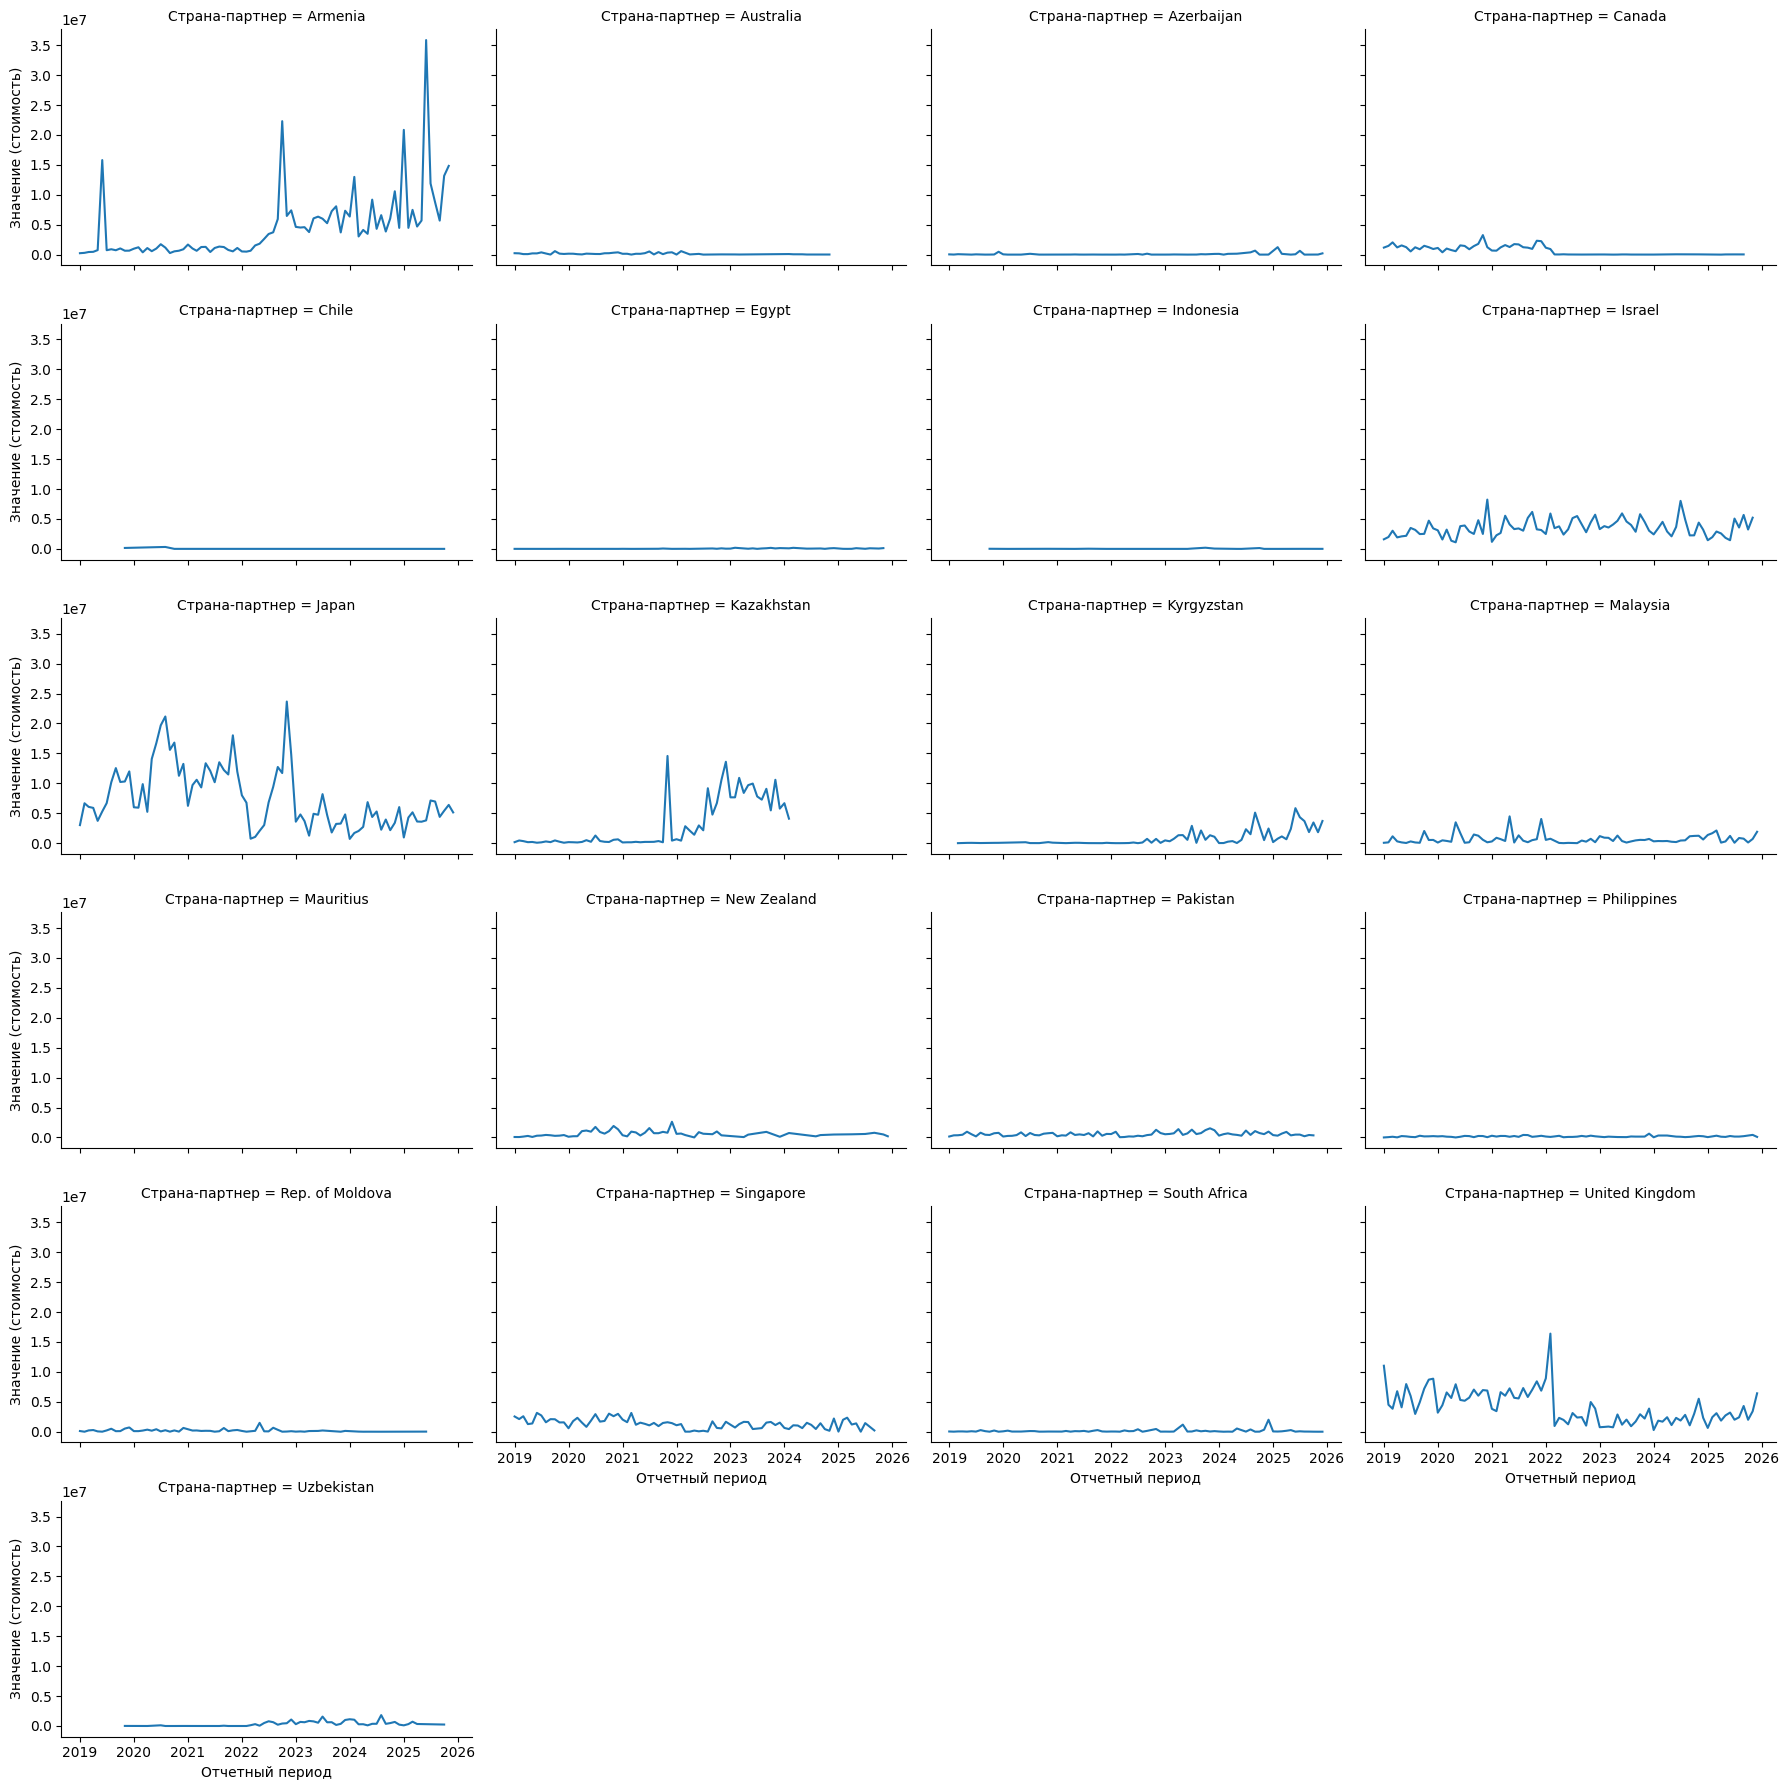

In [24]:
series = comtrade.groupby(['Страна-партнер', 'Отчетный период'], as_index=False)['Значение (стоимость)'].sum()
sns.relplot(
    data=series,
    x='Отчетный период',
    y='Значение (стоимость)',
    col='Страна-партнер',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

In [25]:
comtrade.loc[comtrade['Значение (масса)'] 
    == comtrade['Дополнительная единица измерения (ДЭИ)'], 'Дополнительная единица измерения (ДЭИ)'] = np.nan
comtrade.loc[comtrade['Дополнительная единица измерения (ДЭИ)'].isna(), 'ДЭИ, описание'] = np.nan
comtrade.loc[comtrade['ДЭИ, описание'].isna(), 'Дополнительная единица измерения (ДЭИ)'] = np.nan
comtrade.loc[comtrade['Единица объема'].isna(), 'Значение (масса)'] = np.nan

In [26]:
comtrade['Единица объема'] = comtrade['Единица объема'].str.replace('kg', 'килограмм')
comtrade['Единица объема'] = comtrade['Единица объема'].str.replace('u', 'штук')

Кодовые столбцы и сохраняем файл

In [27]:
comtrade = comtrade.rename(columns={'Отчетный период': 'rep_date', 'Страна-партнер': 'country',
       'Код товара (4 знака)': 'hs', 'Значение (стоимость)': 'value', 'Единица объема': 'unity',
       'Значение (масса)': 'weight', 'ДЭИ, описание': 'alt_unity', 'Дополнительная единица измерения (ДЭИ)': 'alt_weight'})

comtrade = comtrade[['rep_date', 'country', 'hs', 'value', 'weight', 'unity', 'alt_weight', 'alt_unity']]

In [28]:
# БЕЗ МАССЫ

comtrade = comtrade.groupby(['rep_date', 'country', 'hs'], as_index=False)['value'].sum()
comtrade

,rep_date,country,hs,value
0,2019-01-01,Armenia,9018,64738.330
1,2019-01-01,Armenia,9019,15350.530
2,2019-01-01,Armenia,9021,67851.380
3,2019-01-01,Armenia,9025,137.970
4,2019-01-01,Armenia,9027,9867.490
...,...,...,...,...
5133,2025-12-01,South Africa,9031,251.570
5134,2025-12-01,United Kingdom,9018,5440.804
5135,2025-12-01,United Kingdom,9019,1206729.294
5136,2025-12-01,United Kingdom,9021,5204517.236


In [29]:
duplicates = comtrade[
    comtrade.duplicated(
        subset=['rep_date', 'country', 'hs'],
        keep=False
    )
]

duplicates

,rep_date,country,hs,value


Спрогнозируем остаток Австралии

In [30]:
au = comtrade[comtrade['country'] == 'Australia'].copy()
target_date = pd.Timestamp('2025-06-01')
last_actual_date = au['rep_date'].max()
print('Last actual date:', last_actual_date)

forecast_months = pd.date_range(
    start=last_actual_date + pd.offsets.MonthBegin(1),
    end=target_date,
    freq='MS'
)

print('Forecast months:', list(forecast_months))


all_hs = sorted(au['hs'].dropna().unique())
full_months = pd.date_range(au['rep_date'].min(), target_date, freq='MS')

full_grid = pd.MultiIndex.from_product(
    [full_months, all_hs],
    names=['rep_date', 'hs']
).to_frame(index=False)

au_full = full_grid.merge(
    au[['rep_date', 'hs', 'value']],
    on=['rep_date', 'hs'],
    how='left'
)

au_full['country'] = 'Australia'
au_full = au_full.sort_values(['hs', 'rep_date']).reset_index(drop=True)

trend_parts = []

for hs_code, g in au_full.groupby('hs', sort=False):
    g = g.sort_values('rep_date').copy()

    # берем только фактическую историю до последнего реального месяца
    train = g[g['rep_date'] <= last_actual_date].copy()

    # если пропуски есть, заполняем нулями для стабильности тренда
    train['value'] = train['value'].fillna(0.0)

    # индекс времени
    train = train.reset_index(drop=True)
    x = np.arange(len(train))
    y = train['value'].values.astype(float)

    # если мало наблюдений или ряд константный
    if len(train) < 2 or np.all(y == y[0]):
        slope = 0.0
        intercept = y[-1] if len(y) > 0 else 0.0
    else:
        slope, intercept = np.polyfit(x, y, 1)

    preds = []
    start_idx = len(train)

    for step, dt in enumerate(forecast_months):
        x_future = start_idx + step
        pred = intercept + slope * x_future

        # отрицательные значения обрезаем
        pred = max(float(pred), 0.0)

        preds.append({
            'rep_date': dt,
            'country': 'Australia',
            'hs': hs_code,
            'forecast_value': pred,
            'method': 'trend'
        })

    trend_parts.append(pd.DataFrame(preds))

forecast_trend = pd.concat(trend_parts, ignore_index=True)

Last actual date: 2024-11-01 00:00:00
Forecast months: [Timestamp('2024-12-01 00:00:00'), Timestamp('2025-01-01 00:00:00'), Timestamp('2025-02-01 00:00:00'), Timestamp('2025-03-01 00:00:00'), Timestamp('2025-04-01 00:00:00'), Timestamp('2025-05-01 00:00:00'), Timestamp('2025-06-01 00:00:00')]


In [31]:
forecast_trend = forecast_trend.drop(columns='method')
forecast_trend = forecast_trend.rename(columns={'forecast_value': 'value'})
a = pd.concat([comtrade[comtrade['country'] == 'Australia'], forecast_trend])

<Axes: xlabel='rep_date', ylabel='value'>

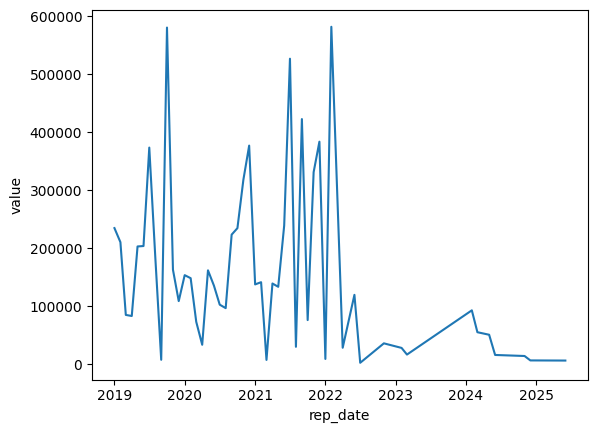

In [32]:
sns.lineplot(x=a.groupby('rep_date', as_index=False)['value'].sum()['rep_date'], y=a.groupby('rep_date', as_index=False)['value'].sum()['value'])

In [33]:
comtrade = comtrade[comtrade['country'] != 'Australia']
comtrade = pd.concat([comtrade, a[a['value'] != 0]])

In [34]:
duplicates = comtrade[
    comtrade.duplicated(
        subset=['rep_date', 'country', 'hs'],
        keep=False
    )
]

duplicates

,rep_date,country,hs,value


In [35]:
comtrade.to_excel('data/comtrade_final.xlsx', index=False)